<h3 style=" color : yellow;"> Problem Statement:</h3>

Segment mall customers into distinct groups based on their spending behavior (Annual Income and Spending Score), so that the marketing team can design targeted strategies for each segment. e.g., premium/high-value customers, moderate spenders, and low-engagement customers.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Mall_Customers.csv")
mall = df.copy()

print(mall.head())
print(mall.tail())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83


In [63]:
print(f"shape of mall customer dataset: {mall.shape}")
print(f"\nduplicates in mall customer dataset: {mall.duplicated().sum()}")
print(f"\ncolumns in mall customer dataset:\n{mall.columns}")
print(f"\ndata types of mall customer dataset:\n{mall.dtypes}")
print(f"\nmissing value of mall customer dataset\n{mall.isnull().sum()}")

shape of mall customer dataset: (200, 5)

duplicates in mall customer dataset: 0

columns in mall customer dataset:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

data types of mall customer dataset:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

missing value of mall customer dataset
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [64]:
#statistical summary
print(f"statistical summary of mall customer dataset: \n {mall.describe(include='all')}")

statistical summary of mall customer dataset: 
         CustomerID  Gender         Age  Annual Income (k$)  \
count   200.000000     200  200.000000          200.000000   
unique         NaN       2         NaN                 NaN   
top            NaN  Female         NaN                 NaN   
freq           NaN     112         NaN                 NaN   
mean    100.500000     NaN   38.850000           60.560000   
std      57.879185     NaN   13.969007           26.264721   
min       1.000000     NaN   18.000000           15.000000   
25%      50.750000     NaN   28.750000           41.500000   
50%     100.500000     NaN   36.000000           61.500000   
75%     150.250000     NaN   49.000000           78.000000   
max     200.000000     NaN   70.000000          137.000000   

        Spending Score (1-100)  
count               200.000000  
unique                     NaN  
top                        NaN  
freq                       NaN  
mean                 50.200000  
std      

In [65]:
mall.drop(columns="CustomerID", inplace=True)

#### Initial Data Observations

The dataset contains 200 rows and originally 5 columns. The CustomerID 
column was dropped since it only contains unique identifiers with no 
predictive or clustering value.

All remaining columns (Gender, Age, Annual Income, Spending Score) have 
correct data types, and there are no missing values or duplicate rows 
the dataset is clean and ready for analysis.

**Statistical Summary:**
- **Age**: Mean (38.85) and median (36) are close, indicating a fairly 
  symmetric distribution. Most customers are between 18–70 years old, 
  with 75% of customers aged 49 or below.
- **Annual Income**: Mean (60.56) and median (61.5) are close, but the 
  maximum (137) is noticeably far from the 75th percentile (78) this 
  suggests a few high-income outliers pulling the upper range.
- **Spending Score**: Mean (50.2) and median (50) are almost identical, 
  suggesting a well-balanced, symmetric distribution. Scores range from 
  1 to 99.
- **Gender**: The dataset has 112 Female and 88 Male customers — a 
  reasonably balanced split.

In [ ]:
#renaming columns for better understanding
mall = mall.rename(columns={'Annual Income (k$)' : 'annual_income', 'Spending Score (1-100)' : 'spending_score', 'Age' : 'age', 'Gender' : 'gender'})

### Exploratory data analysis

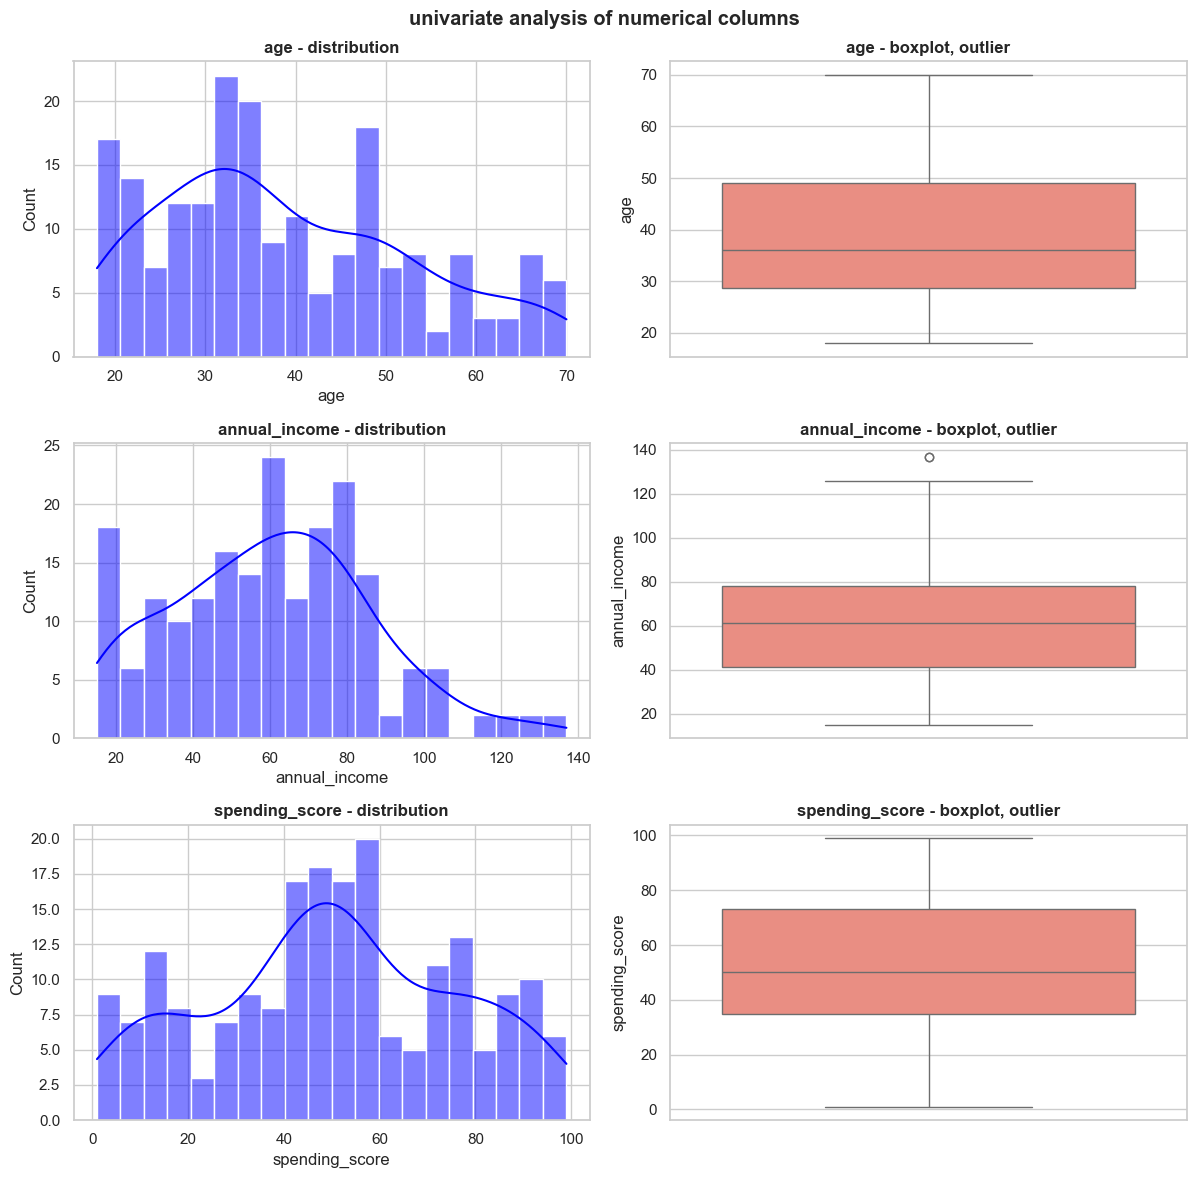

In [67]:
#Univariate analysis of numerical columns:
sns.set_theme(style="whitegrid")

uni_col = ["age", "annual_income", "spending_score"]

fig, axes = plt.subplots(3, 2, figsize=(12,12))

for i, col, in enumerate(uni_col):
    sns.histplot(data=mall, x=col, kde=True, color="blue", ax=axes[i][0], bins=20)
    axes[i][0].set_title(f"{col} - distribution", weight='bold')

    sns.boxplot(data=mall, y=col, color="salmon", ax=axes[i][1])
    axes[i][1].set_title(f"{col} - boxplot, outlier", weight='bold')

plt.suptitle(f"univariate analysis of numerical columns", weight = 'bold')
plt.tight_layout()
plt.show()




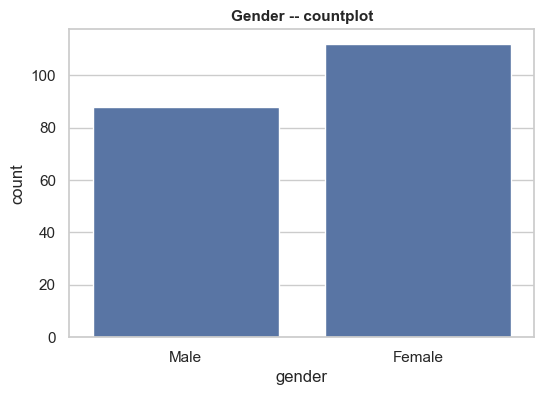

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(data=mall, x='gender')
plt.title(f"Gender -- countplot",  fontsize=11, weight='bold')
plt.show()


### Observation
Univariate Analysis - Numerical Columns 
<br>Age: Distribution is fairly spread out with peaks around 32-35 and 48. No outliers in the boxplot. Median age is 36.
<br>Annual Income: Distribution is slightly right skewed, with most customers earning between 60k-80k. One clear outlier exists above 120k. Median income is 61.5k.
<br> Spending Score: Most customers have a spending score between 40-60. Score around 20 has the lowest count. No outliers.

<br>Univariate Analysis - Categorical Column
<br>Gender: Female customers (112) are higher in count than male customers (88).

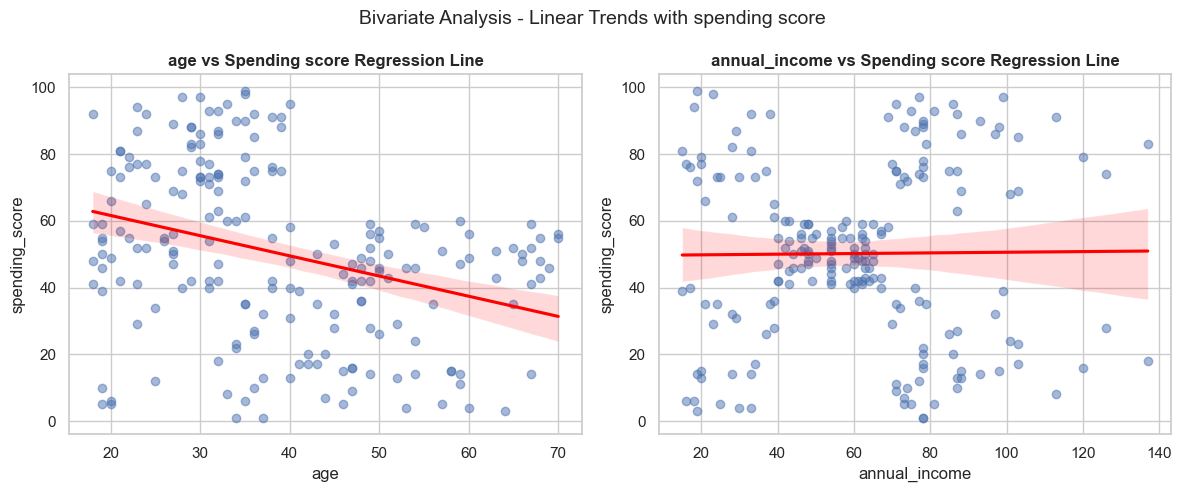

In [69]:
bi_num_col= ["age", "annual_income"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for i, col, in enumerate(bi_num_col):
    # regplot maps x and y directly; it does not use 'hue'
    sns.regplot(data=mall, x=col, y="spending_score", ax=axes[i], 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[i].set_title(f"{col} vs Spending score Regression Line", weight='bold')

plt.suptitle("Bivariate Analysis - Linear Trends with spending score", fontsize=14)
plt.tight_layout()
plt.show()

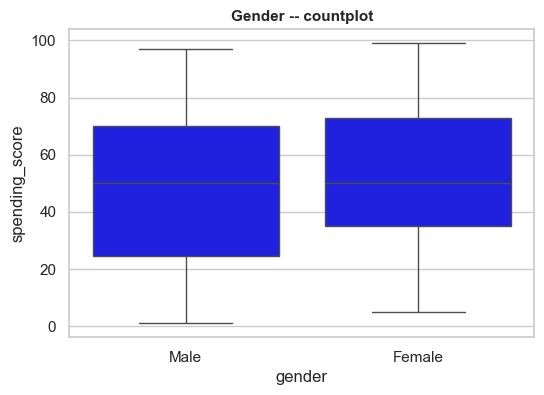

In [70]:
plt.figure(figsize=(6,4))
sns.boxplot(data=mall, x='gender', y="spending_score", color='blue')
plt.title(f"Gender -- countplot",  fontsize=11, weight='bold')
plt.show()

Bivariate Analysis<br>
Age vs Spending Score: Clear negative trend. As age increases, spending score decreases. Younger customers tend to have higher spending scores, older customers lower.<br>
Annual Income vs Spending Score: Regression line is almost flat, showing no linear relationship. However, this does not mean there is no pattern at all — a flat line only rules out a simple straight-line relationship. Since scatter points are still highly spread out on both high and low ends, this hints that the real structure might be non-linear or exist in the form of separate groups/clusters, which we'll investigate further with clustering.<br>
Bivariate Analysis - Categorical<br>
Gender vs Spending Score: Both genders have almost the same median spending score (around 45-50). A few female customers have higher spending scores than males, and females show a slightly larger lower whisker range.

In [71]:
#converting gender into numerical so we can observe it in heatmao
mall['gender'] = mall['gender'].map({'Male': 0, 'Female': 1})

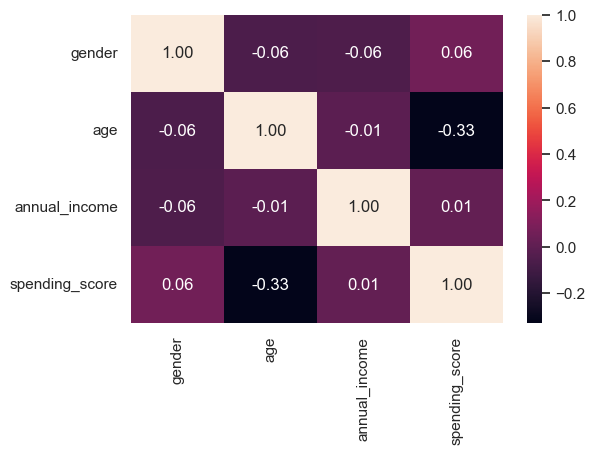

In [72]:
plt.figure(figsize=(6,4))
corr = mall.corr(numeric_only=True)
sns.heatmap(data=corr, annot=True, fmt='.2f')
plt.show()

Age shows the strongest relationship in the heatmap, with a negative correlation of -0.33 against Spending Score — this confirms our earlier bivariate finding that older customers tend to have lower spending scores.<br>
Gender and Annual Income show very weak correlations (close to 0) with all other variables, suggesting they don't have a simple linear relationship with spending behavior.<br>
* Important note:  Although Annual Income shows almost 0 correlation with Spending Score in this heatmap, this doesn't mean there's no relationship at all — correlation only measures linear relationships. As seen in the reg plot earlier, the data appears to form distinct groups (clusters) rather than a straight-line pattern, so a low correlation value can still hide meaningful structure that clustering will reveal.

In [73]:
#scaling so alogorithm does not make difference between columns
from sklearn.preprocessing import StandardScaler
mall_scaled = mall.copy()
scale = StandardScaler()
cols_to_scale = ['age', 'annual_income', 'spending_score']
mall_scaled[cols_to_scale] = scale.fit_transform(mall_scaled[cols_to_scale])

mall_scaled.head()

,gender,age,annual_income,spending_score
0,0,-1.424569,-1.738999,-0.434801
1,0,-1.281035,-1.738999,1.195704
2,1,-1.352802,-1.700830,-1.715913
3,1,-1.137502,-1.700830,1.040418
4,1,-0.563369,-1.662660,-0.395980


### Finding optimal K

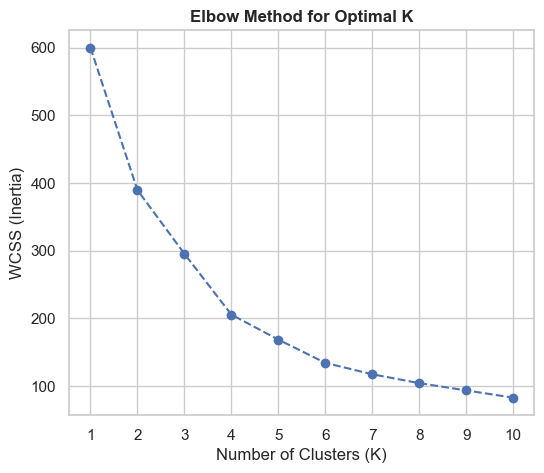

WCSS values: [600.0, 389.3861889564371, 295.2122461555488, 205.22514747675922, 168.24758017556837, 133.86842085478852, 117.01155455889811, 103.87329152383714, 93.09289110041726, 82.38515364526597]


In [74]:
import warnings
from sklearn.cluster import KMeans

# use this toHide all warnings
warnings.filterwarnings("ignore", category=UserWarning)
scaled_data = mall_scaled.drop(columns='gender').copy()

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title("Elbow Method for Optimal K", weight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(K_range)
plt.grid(True)
plt.show()
print("WCSS values:", wcss)

K=2, Silhouette Score=0.3355
K=3, Silhouette Score=0.3578
K=4, Silhouette Score=0.4040
K=5, Silhouette Score=0.4166
K=6, Silhouette Score=0.4284
K=7, Silhouette Score=0.4172
K=8, Silhouette Score=0.4082
K=9, Silhouette Score=0.4177
K=10, Silhouette Score=0.4066


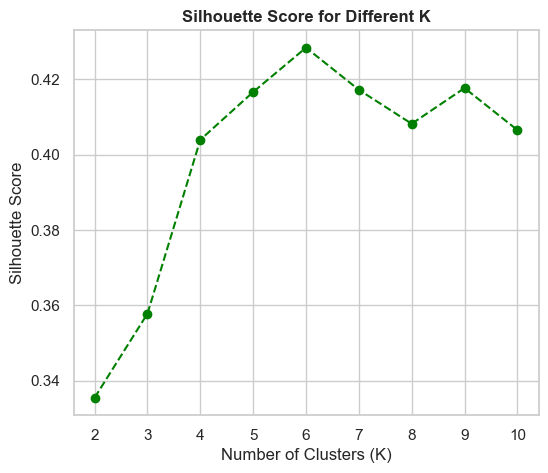

In [75]:
from sklearn.metrics import silhouette_score


silhouette_scores = []
K_range = range(2, 11)  # silhouette needs at least 2 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(6,5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--', color='green')
plt.title("Silhouette Score for Different K", weight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [76]:
from sklearn.metrics import davies_bouldin_score

db_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = davies_bouldin_score(scaled_data, labels)
    db_scores.append(score)
    print(f"K={k}, Davies-Bouldin Index={score:.4f}")


K=2, Davies-Bouldin Index=1.2607
K=3, Davies-Bouldin Index=1.0503
K=4, Davies-Bouldin Index=0.9308
K=5, Davies-Bouldin Index=0.8746
K=6, Davies-Bouldin Index=0.8254
K=7, Davies-Bouldin Index=0.7935
K=8, Davies-Bouldin Index=0.8918
K=9, Davies-Bouldin Index=0.8198
K=10, Davies-Bouldin Index=0.8679


## Choosing Optimal K

After trying three methods (Elbow Method, Silhouette Score, and Davies-Bouldin 
Index), we observed that each method suggested a different optimal K:

- Elbow Method suggested K=4
- Silhouette Score suggested K=6
- Davies-Bouldin Index suggested K=7

Since all three metrics disagreed, we made a business-oriented decision and 
chose K=5. Although Davies-Bouldin's best score was at K=7, K=5 was its 
second-best value. Similarly, K=5 was very close to the best Silhouette 
Score (K=6), and Elbow Method also showed K=4-5 as a reasonable range. 
K=5 therefore offers a good balance across all three metrics while also 
being easier to interpret and act on from a marketing perspective.

### K-Mean ML model

In [77]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
mall['cluster'] = kmeans.fit_predict(scaled_data)

print(mall.head())
print("\nCluster counts:")
print(mall['cluster'].value_counts().sort_index())

   gender  age  annual_income  spending_score  cluster
0       0   19             15              39        1
1       0   21             15              81        1
2       1   20             16               6        0
3       1   23             16              77        1
4       1   31             17              40        1

Cluster counts:
cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


In [78]:
cluster_averages = mall.groupby('cluster')[['age','annual_income','spending_score']].mean()
print(cluster_averages)

               age  annual_income  spending_score
cluster                                          
0        46.250000      26.750000       18.350000
1        25.185185      41.092593       62.240741
2        32.875000      86.100000       81.525000
3        39.871795      86.102564       19.358974
4        55.638298      54.382979       48.851064


## Cluster Profiling

**Cluster 2** (Avg Income: 86, Avg Spending Score: 81, Avg Age: 32)
High income and high spending. These are our Premium Customers — 
financially capable and willing to spend.

**Cluster 3** (Avg Income: 86, Avg Spending Score: 19)
High income but low spending score. These customers save rather than 
spend, despite having the means to do so. Classified as Cautious/Saver 
Customers — high potential but currently underspending.

**Cluster 1** (Avg Income: 41, Avg Spending Score: 62, Avg Age: 25)
Below-average income but the second-highest spending score. This is 
a young segment (avg age 25) that spends relatively freely despite 
limited income. Classified as Impulsive/Young Spenders — a strong 
target for discounts and promotional offers.

**Cluster 4** (Avg Income: 54, Avg Spending Score: 48, Avg Age: 55)
Moderate income and moderate spending. Classified as Average/Middle 
Customers — balanced but not particularly high-value or high-growth.

**Cluster 0** (Avg Income: 26, Avg Spending Score: 18)
Low income and low spending score. Classified as Low-Budget Customers. 
Worth noting: despite low income, there is some spending activity, 
suggesting they might respond well to discounts or value-based offers.

In [79]:
#Creating a columns segment to assign name according to cluster
mall["segment"] = mall["cluster"].map({0 : "Budget Customers", 1 : "Young Spenders", 2 : "Premium Customers", 3 : "Cautious Savers", 4 : "Average Customers"})
mall.head()

,gender,age,annual_income,spending_score,cluster,segment
0,0,19,15,39,1,Young Spenders
1,0,21,15,81,1,Young Spenders
2,1,20,16,6,0,Budget Customers
3,1,23,16,77,1,Young Spenders
4,1,31,17,40,1,Young Spenders


### PCA (Principal component analysis)

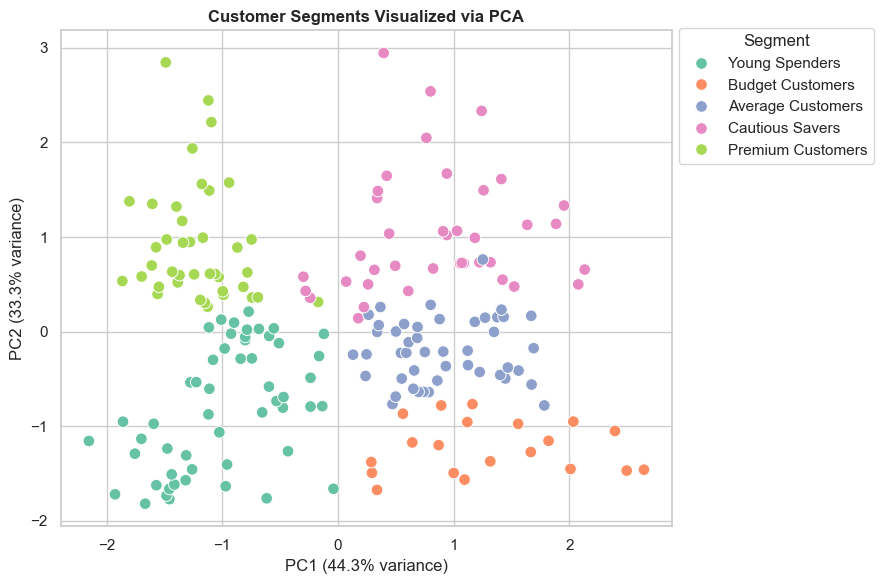

In [80]:
# PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
mall['PC1'] = pca_result[:, 0]
mall['PC2'] = pca_result[:, 1]

plt.figure(figsize=(9,6))
sns.scatterplot(data=mall, x='PC1', y='PC2', hue='segment', palette='Set2', s=70)
plt.title("Customer Segments Visualized via PCA", weight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title='Segment', bbox_to_anchor=(1, 1.02), loc='upper left')
plt.tight_layout()
plt.show()


The PCA scatter plot shows 5 clearly separated clusters, confirming 
that K-Means was able to find distinct customer groups. The two 
principal components together capture 77.6% of the total variance 
(PC1: 44.3%, PC2: 33.3%), which is reasonably good for a 2D visualization.

Premium Customers (green) are positioned furthest from other segments, 
indicating they are the most distinct group. Young Spenders (teal) and 
Budget Customers (orange) are both positioned in the lower half of the 
plot, suggesting some similarity between them on one dimension, but 
they remain clearly separated horizontally. Cautious Savers (pink) and 
Average Customers (blue) occupy the middle-to-upper region with some 
closeness, but still form distinguishable groups.

<center><h3 style=" color : yellow;"> Marketing Strategies by Segment</h3> </center>

- <h5 style="text-decoration: underline;">Premium Customers (High Income, High Spending)</h5>
No need for heavy discounts, since they already spend freely. Focus instead on exclusive/VIP experiences — early access to new products, premium loyalty programs, and personalized service. Discounting this segment would reduce profit margins unnecessarily since they're already engaged.
- <h5 style="text-decoration: underline;">Cautious Savers (High Income, Low Spending)</h5>
This is the highest-potential untapped segment. Since they have the money but aren't spending, the strategy should focus on building trust and highlighting value — curated recommendations, top-rated products, and quality assurance. Targeted discounts or limited-time offers could help push them from "saving" to "spending."
- <h5 style="text-decoration: underline;">Young Spenders (Lower-Mid Income, High Spending, Young Age)</h5>
Already highly engaged and willing to spend despite limited income. Respond well to discounts, flash sales, and trend-driven promotions (social media-linked offers, loyalty points, buy-now-pay-later options) to keep them engaged without straining their budget.
- <h5 style="text-decoration: underline;">Average Customers (Moderate Income, Moderate Spending)</h5>
Standard, broad-appeal marketing — regular seasonal discounts, bundle deals, and email/app-based promotions to gradually nudge them toward higher engagement.
- <h5 style="text-decoration: underline;">Budget Customers (Low Income, Low Spending)</h5>
Despite low income, they show willingness to spend, making them responsive to value-driven offers. Strategy: deep discounts, free shipping, entry-level product bundles, and loyalty/rewards programs to build long-term engagement.

## Conclusion / Summary

**Data Quality:** The dataset was clean, with no missing or duplicate 
values, making it ready for analysis without additional cleaning.

**Univariate Analysis:** Age distribution was fairly spread with no 
strong skew. Annual Income appeared roughly symmetric, though a few 
high-value outliers pulled the distribution slightly to the right. 
Female customers were slightly more common than male customers.

**Bivariate Analysis:** Using regression plots, Age showed a clear 
negative relationship with Spending Score (-0.33), meaning younger 
customers tend to have higher spending scores. Annual Income showed 
no linear relationship with Spending Score (near-flat regression line). 
However, this doesn't mean there's no relationship at all, it only 
means the relationship isn't linear. This was later confirmed by 
clustering, which revealed distinct customer groups based on income 
and spending patterns that a simple correlation could not capture.

**Finding Optimal Clusters:** After scaling the data, three methods 
were used to determine the optimal number of clusters. The Elbow Method 
suggested 4, Silhouette Score suggested 6, and Davies-Bouldin Index 
suggested 7 (with 5 as a close second). Since all three metrics 
disagreed, K=5 was selected as a business-friendly balance that 
performed reasonably well across all three methods.

**Clustering and Profiling:** K-Means was applied with K=5, and 
cluster-wise averages (Age, Income, Spending Score) were calculated 
using groupby to understand each group's characteristics. Based on 
these profiles, the segments were labeled as:
- Cluster 0: Budget Customers
- Cluster 1: Young Spenders
- Cluster 2: Premium Customers
- Cluster 3: Cautious Savers
- Cluster 4: Average Customers

**Visualization:** PCA was used to reduce the 3 features into 2 
components for visualization, capturing 77.6% of the total variance. 
The scatter plot confirmed that the clusters were reasonably well 
separated, with Premium Customers appearing as the most distinct group.

**Business Outcome:** Each segment was matched with a tailored 
marketing strategy, ranging from loyalty programs for Premium 
Customers to discount-driven offers for Budget Customers and Cautious 
Savers, enabling more targeted and effective marketing decisions.